In [7]:
import pandas as pd  # is used for data manipulation.
import numpy as np  # helps with numerical operation

In [1]:
import pandas as pd

# Define the file path and chunk size
file_path = '/Users/rukmangadaruku/Library/CloudStorage/OneDrive-TheUniversityofTexasatDallas/Sem 2/Machine Learning/Project Final/train_data.csv'
chunk_size = 1000000

# Initialize an empty DataFrame to store the combined data
combined_data = pd.DataFrame()

# Create a reader to load the data in chunks
chunk_iter = pd.read_csv(file_path, chunksize=chunk_size)

# Iterate over the chunks and concatenate them immediately to the `combined_data` DataFrame
for chunk in chunk_iter:
    combined_data = pd.concat([combined_data, chunk], ignore_index=True)

# After all chunks are processed, the `combined_data` DataFrame contains all the data
print(f"Combined data shape: {combined_data.shape}")


Combined data shape: (5531451, 190)


In [15]:
train_labels = pd.read_csv('/Users/rukmangadaruku/Library/CloudStorage/OneDrive-TheUniversityofTexasatDallas/Sem 2/Machine Learning/Project Final/train_labels.csv')

In [16]:
train_labels.shape

(458913, 2)

In [17]:
train_lables_Sample = train_labels.sample(frac=0.2, random_state=42)

In [18]:
train_filt_label_data = pd.merge(train_lables_Sample,train_data,on='customer_ID',how='inner')
train_filt_label_data

,customer_ID,target,S_2,P_2,D_39,B_1,B_2,R_1,S_3,D_41,...,D_136,D_137,D_138,D_139,D_140,D_141,D_142,D_143,D_144,D_145
0,12c761e40348fa242de0356426fa9547f0feea34d1f57b...,0,2017-03-21,0.628534,0.004250,0.017667,0.815468,0.005736,0.265531,0.005933,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,12c761e40348fa242de0356426fa9547f0feea34d1f57b...,0,2017-04-21,0.669914,0.418321,0.354284,1.000587,0.009774,0.176196,0.007370,...,NaN,NaN,NaN,0.003869,0.008332,0.005805,NaN,0.006603,0.007874,0.002185
2,12c761e40348fa242de0356426fa9547f0feea34d1f57b...,0,2017-05-08,0.661933,0.003989,0.244867,1.008683,0.005743,0.169471,0.005953,...,NaN,NaN,NaN,0.004872,0.008471,0.006763,NaN,0.009782,0.007285,0.000121
3,12c761e40348fa242de0356426fa9547f0feea34d1f57b...,0,2017-06-14,0.644270,0.009351,0.017799,0.668398,0.003148,0.174020,0.006656,...,NaN,NaN,NaN,0.009246,0.009905,0.008673,NaN,0.003927,0.001159,0.000433
4,12c761e40348fa242de0356426fa9547f0feea34d1f57b...,0,2017-07-26,0.688055,0.002832,0.009458,0.779692,0.000870,0.174547,0.009100,...,NaN,NaN,NaN,0.004311,0.006488,0.004953,NaN,0.009283,0.003769,0.006124
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1107077,f0defebbf6e79c14234a06c5b3522ee5914cb0f23fdd13...,0,2017-11-29,0.957207,0.003413,0.005511,0.811611,0.007821,NaN,0.002437,...,NaN,NaN,NaN,0.003099,0.000731,0.006184,NaN,0.006376,0.003519,0.007407
1107078,f0defebbf6e79c14234a06c5b3522ee5914cb0f23fdd13...,0,2017-12-30,0.826494,0.007873,0.009774,0.819318,0.007074,NaN,0.006983,...,NaN,NaN,NaN,0.007693,0.001338,0.001450,NaN,0.003571,0.001993,0.005287
1107079,f0defebbf6e79c14234a06c5b3522ee5914cb0f23fdd13...,0,2018-01-30,0.828001,0.002666,0.001569,0.815946,0.001636,NaN,0.005888,...,NaN,NaN,NaN,NaN,0.006918,NaN,NaN,NaN,0.001155,NaN
1107080,f0defebbf6e79c14234a06c5b3522ee5914cb0f23fdd13...,0,2018-02-27,0.825479,0.001338,0.006197,0.812589,0.000352,NaN,0.003774,...,NaN,NaN,NaN,0.009021,0.006564,0.000960,NaN,0.001825,0.006149,0.009502


In [19]:
unique_customers = train_filt_label_data['customer_ID'].nunique()
unique_customers

91783

In [10]:
train_filt_label_data.to_csv("train_filt_label_data.csv")

In [11]:
from copy import deepcopy

temp_df = deepcopy(train_filt_label_data)

temp_df['temp_yearmonth']=train_filt_label_data.S_2.str.slice(0,7)

 
def_obs = temp_df[temp_df.target==1].groupby(['temp_yearmonth'],as_index=False)[['customer_ID']].count()

def_obs = def_obs.rename(columns={'customer_ID':'default_observation'})
 
tot_obs = temp_df.groupby(['temp_yearmonth'],as_index=False)[['customer_ID']].count()

tot_obs = tot_obs.rename(columns={'customer_ID':'total_observations'})
 
combined_obs = def_obs.merge(tot_obs,on=['temp_yearmonth'])

combined_obs['default_rate_per_month']=round(combined_obs.default_observation/combined_obs.total_observations,4)

combined_obs
 

,temp_yearmonth,default_observation,total_observations,default_rate_per_month
0,2017-03,18209,79285,0.2297
1,2017-04,18824,80471,0.2339
2,2017-05,18928,80174,0.2361
3,2017-06,19686,82129,0.2397
4,2017-07,20221,83211,0.2430
5,2017-08,20722,84262,0.2459
6,2017-09,21125,85149,0.2481
7,2017-10,21538,86072,0.2502
8,2017-11,21898,86876,0.2521
9,2017-12,22302,87783,0.2541


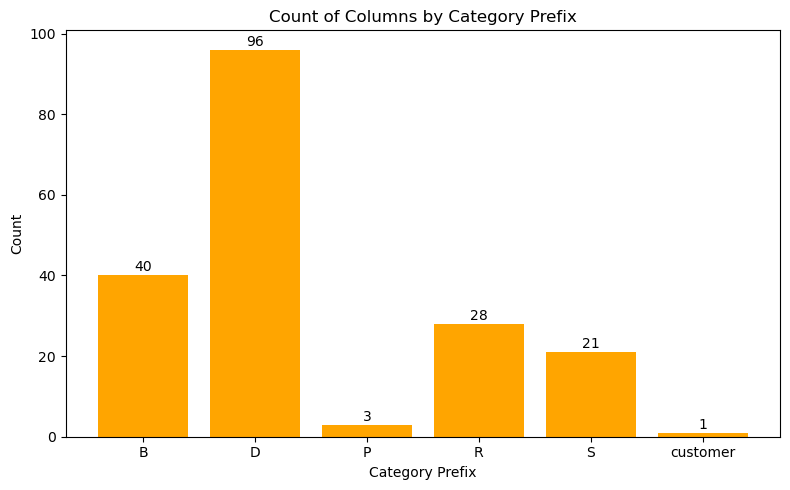

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Step 1: Load the first chunk of the training data to get column names
# You only need the first row to inspect structure
train_sample = pd.read_csv("Data/train_data.csv", nrows=1)  # Update path if needed
columns = train_sample.columns.tolist()

# Step 2: Extract prefixes (like D, S, P, B, R)
prefixes = [col.split('_')[0] for col in columns if '_' in col and col != 'S_2']

# Step 3: Count how many columns fall under each prefix
prefix_counts = dict(Counter(prefixes))
prefix_df = pd.DataFrame(list(prefix_counts.items()), columns=["Category Prefix", "Count"]).sort_values(by="Category Prefix")

# Step 4: Plot the results
plt.figure(figsize=(8, 5))
bars = plt.bar(prefix_df["Category Prefix"], prefix_df["Count"], color='Orange')

# Add count labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 1, str(int(height)), ha='center', fontsize=10)

plt.title("Count of Columns by Category Prefix")
plt.xlabel("Category Prefix")
plt.ylabel("Count")
plt.tight_layout()

# Step 5: Save chart (optional)
plt.savefig("Category_Prefix_Counts_From_Real_Data.png")
plt.show()


In [7]:
# Step 1: Calculate the total count of null values and their percentages
Count_Null = train_filt_label_data.isnull().sum()
Count_Null_percentage = ((train_filt_label_data.isnull().sum() / len(train_filt_label_data)) * 100).round(2)
null_df = pd.DataFrame({
    'Null Value Count': Count_Null,
    'Null Value Percent(%)': Count_Null_percentage
})
null_df_sorted = null_df.sort_values(by='Null Value Count', ascending=False)
null_df_sorted

,Null Value Count,Null Value Percent(%)
D_87,1106268,99.93
D_88,1105909,99.89
D_108,1101423,99.49
D_110,1100434,99.40
D_111,1100434,99.40
...,...,...
D_96,0,0.00
B_36,0,0.00
R_24,0,0.00
D_127,0,0.00


In [8]:
# Count features with more than 20% missing values
features_to_drop = null_df_sorted[null_df_sorted['Null Value Percent(%)'] > 20].index.tolist()
count_dropped_features = len(features_to_drop)

# Drop the features with more than 20% missing values
train_date_filtered = train_filt_label_data.drop(columns=features_to_drop)

# Output the results
print(f"Count of features with more than 20% missing values: {count_dropped_features}")
print("Dropped features:", features_to_drop)

Count of features with more than 20% missing values: 34
Dropped features: ['D_87', 'D_88', 'D_108', 'D_110', 'D_111', 'B_39', 'D_73', 'B_42', 'D_138', 'D_135', 'D_134', 'D_137', 'D_136', 'R_9', 'B_29', 'D_106', 'D_132', 'D_49', 'R_26', 'D_66', 'D_76', 'D_42', 'D_142', 'D_53', 'D_82', 'D_50', 'B_17', 'D_105', 'D_56', 'S_9', 'D_77', 'D_43', 'S_27', 'D_46']


In [9]:
cat_feature = ['B_30', 'B_38', 'D_114', 'D_116', 'D_117', 'D_120', 'D_126', 'D_63', 'D_64', 'D_68']

train_encoded = pd.get_dummies(train_filt_label_data,columns=cat_feature,drop_first=False)

In [10]:
cols_with_B30 = train_encoded.filter(like='B_30').columns.tolist()

print(cols_with_B30)

['B_30_0.0', 'B_30_1.0', 'B_30_2.0']


In [11]:
train_filt_label_data.shape

(1107082, 191)

In [12]:
train_encoded.shape

(1107082, 224)

In [13]:
train_encoded.to_csv('01_Data_Download_Preprocessing_onehotencoding.csv')